# 🚂 TARDIS Project — PREDICTING THE UNPREDICTABLE
***

### 👥 The Research Team :
* **Raphaël Permentier**
* **Stan Gaumain**
* **Come Chaslerie**

---
### 🎯 **Our Mission:** 

**Analyse train database, find out why trains are late, and build a program to predict train delays before they happen.**

---
### 🔍 **Preliminary Step**

**To do this, we first looked closely at our data. We found some mistakes and missing information. We need to clean and fix these problems before we can build our prediction models.**

---
##### **First, we load the file containing the database so that we can modify it :**

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#load all mendatory lib

#put name of the file in filepath variable
filepath = "dataset.csv"
#load the file in variable df (Dataframe)
df = pd.read_csv(filepath, sep=";")

# 🧼 **CLEANING THE DATASET** #

---
### 🛠️ **Cleaning the Dataset**
---

To clean our data, we follow these simple steps:

* **1. Fix Data Types** We change each column to the right type. For example, we convert text into numbers so the computer can read them correctly.
  
* **2. Remove Broken Rows** We delete rows that are missing important information because we cannot use them.
  
* **3. Fill Empty Spaces** If some columns have missing values, we fill them with 0, None or an average number.
  
* **4. Clean Extra Spaces** We remove invisible spaces at the beginning and the end of text columns (like station names) so they match perfectly.
  
* **5. Create New Columns** We build new information (features) from our data to help our prediction models work better later.

* **6. Delete Useless Columns** We remove text columns (like comments) that we do not need for our machine learning models.

* **7. Export Cleaned Dataset** We save our final, perfectly clean data into a new CSV file.
---

### ♻️ **Step 1 : Convert all columns to the appropriate type :**

**the columns type before :**

In [50]:
#print all columns type
print(df.dtypes)

Date                                                                             str
Service                                                                          str
Departure station                                                                str
Arrival station                                                                  str
Average journey time                                                             str
Number of scheduled trains                                                       str
Number of cancelled trains                                                       str
Cancellation comments                                                            str
Number of trains delayed at departure                                            str
Average delay of late trains at departure                                        str
Average delay of all trains at departure                                         str
Departure delay comments                                         

⚠️ **The Problem:**
Right now, some columns have the wrong data type. This will cause errors when we try to use the data in our models.

💡 **Our Fix:**
We write code to fix this. It automatically changes text columns into strings and number columns into numbers.

In [51]:
cols_to_num = [
    'Average journey time', 
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)'
]

cols_to_string = [
    'Service',
    'Departure station',
    'Arrival station',
    'Cancellation comments',
    'Departure delay comments',
    'Arrival delay comments'
]

#repeats the transformation for each column of the "cols_to_num" list
for col_num in cols_to_num:
    #convert columns to a str type
    df[col_num] = df[col_num].astype("string")
    #replace all ',' to '.' to transform into numeric
    df[col_num] = df[col_num].str.replace(',', '.')
    #Remove all the "min" characters so that you can then convert to numeric without any problems.
    df[col_num] = df[col_num].str.replace(' min', '')
    #Remove all the "%" characters so that you can then convert to numeric without any problems.
    df[col_num] = df[col_num].str.replace('%', '')
    #Converted the column to numeric type (string to numeric)
    df[col_num] = pd.to_numeric(df[col_num], errors='coerce')
for col_str in cols_to_string:
    #convert columns to a str type
    df[col_str] = df[col_str].astype("string")
#convert columns 'Date' to a datetime type with format year-month
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m', errors='coerce')
#Keep only the months and years to ensure the data has the same format.
df['Date'] = df['Date'].dt.to_period('M')

**The columns type after conversion :**

In [52]:
print(df.dtypes)

Date                                                                             period[M]
Service                                                                             string
Departure station                                                                   string
Arrival station                                                                     string
Average journey time                                                               Float64
Number of scheduled trains                                                         Float64
Number of cancelled trains                                                         Float64
Cancellation comments                                                               string
Number of trains delayed at departure                                              Float64
Average delay of late trains at departure                                          Float64
Average delay of all trains at departure                                           Float64

#### 👀 **We can observe that the column types are now adapted and are therefore easier to use in our models later.**

---

### 🗑️ **Step 2 : remove unsable line :**

**The number of line before delete unsable line :**

In [53]:
#put in nb_line_before the number of line of df
nb_line_before = len(df)

In [54]:
#list of columns that are designated as mandatory (if a value is null in one of these columns it is unusable)
mandatory_data = [
    'Date',
    'Departure station',
    'Arrival station',
]
#delete the rows that contain at least one null value among the "mendatory" columns
df = df.dropna(subset=mandatory_data)

#delete all duplicates lines
df = df.drop_duplicates()

The number of line after delete unsable line :

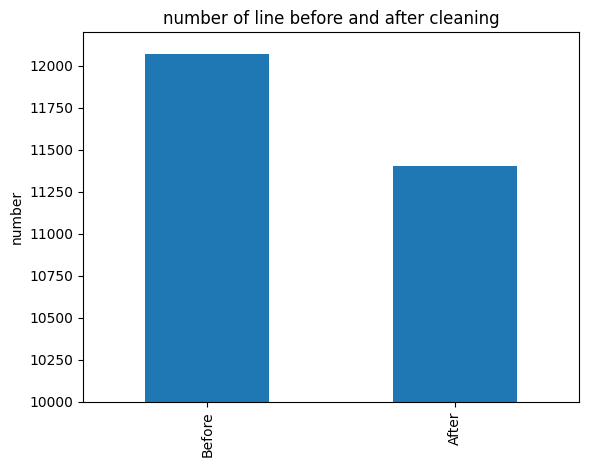

In [55]:
#put in nb_line_after the number of line of df
nb_line_after = len(df)
#Create a data list with Before and After value
data = pd.Series({'Before': nb_line_before, 'After': nb_line_after})
#select bar graphic style
data.plot(kind='bar')
#add title to the graphic
plt.title("number of line before and after cleaning")
#add label to the y axe
plt.ylabel("number")
#add limite to y axe
plt.ylim(10000, 12200)
#show graphic
plt.show()

✅ **Result:** The chart shows that the broken rows were successfully removed. Our code worked correctly!

***
### 🩹 **Step 3 : Handling all null or missing values :**

📋 **Our Strategy :** Not all missing values (NaN) should be treated the same way. We use different rules depending on the column :

* **Text Columns:** We replace missing comments with `"None"` so we know there was no comment.
* **Number Columns:** We replace missing counts or percentages with `0` because it means nothing happened.
* **Journey Time:** We replace missing times with the **median** (the middle value). This fixes the empty spaces without changing the overall statistics.

Number of null values ​​in each column before :

In [56]:
#print the number of null value in each columns
print(df.isnull().sum())

Date                                                                                 0
Service                                                                            227
Departure station                                                                    0
Arrival station                                                                      0
Average journey time                                                               228
Number of scheduled trains                                                         227
Number of cancelled trains                                                         228
Cancellation comments                                                            10858
Number of trains delayed at departure                                              222
Average delay of late trains at departure                                          228
Average delay of all trains at departure                                           226
Departure delay comments                   

In [57]:
null_val_to_zero = [
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)'
]

#replaces all null values ​​in the "cols_to_string" list with "None"
df[cols_to_string] = df[cols_to_string].fillna("None")
#replaces all null values ​​in the "null_val_to_zero" list with "0"
df[null_val_to_zero] = df[null_val_to_zero].fillna(0)
#recovery of median travel time
median_val = df['Average journey time'].median()
#Replacing null values ​​in the "Average journey time" column with the median value allows the rows to be used without impacting the average journey time result.
df['Average journey time'] = df['Average journey time'].fillna(median_val)

**Number of null values ​​in each column after :**

In [58]:
#print the number of null value in each columns
print(df.isnull().sum())

Date                                                                             0
Service                                                                          0
Departure station                                                                0
Arrival station                                                                  0
Average journey time                                                             0
Number of scheduled trains                                                       0
Number of cancelled trains                                                       0
Cancellation comments                                                            0
Number of trains delayed at departure                                            0
Average delay of late trains at departure                                        0
Average delay of all trains at departure                                         0
Departure delay comments                                                         0
Numb

✅ **Result:** we now have no null values !

***
## 🧹 Step 4: Clean Extra Spaces
***

### 💡 **Our Strategy:**
**Sometimes, text columns like station names have invisible spaces at the beginning or the end (for example: `" PARIS LYON "` instead of `"PARIS LYON"`).** 
**We use the `.str.strip()` command to remove these hidden spaces so the text matches perfectly.**

In [59]:
# Remove invisible spaces from the 'Service' column
df['Service'] = df['Service'].str.strip()
# Remove invisible spaces from the 'Departure station' column
df['Departure station'] = df['Departure station'].str.strip()
# Remove invisible spaces from the 'Arrival station' column
df['Arrival station'] = df['Arrival station'].str.strip()

***
## 🏗️ Step 5: Create New Columns
***

### 📊 **Our Strategy:**
**To help our future prediction models, we extract new information from the `Date` column: the month, the year, and the quarter.**
**We also create a `delay_category` column by rounding the arrival delays to the nearest minute.**

In [60]:
# Extract the month number from the Date column
df['Month'] = df['Date'].dt.month
# Extract the year number from the Date column
df['Year'] = df['Date'].dt.year
# Extract the quarter number (1 to 4) from the Date column
df['semester'] = df['Date'].dt.quarter
# Round the arrival delay to create a category column
df['delay_category'] = df['Average delay of all trains at arrival'].round()

***
## 🗑️ Step 6: Delete Useless Columns
***

### ❌ **Our Strategy:**
**The comment columns contain too much text and are not useful for our prediction models. We delete them to keep our dataset clean and lightweight.**

In [61]:
columns_to_delete = [
   'Arrival delay comments',
   'Cancellation comments',
   'Departure delay comments'
]

# Drop the selected columns from the dataset
df = df.drop(columns_to_delete, axis=1)

***
## 💾 Step 7: Export Cleaned Dataset
***

### 🚀 **Final Result:**
**Our data is now perfectly clean with no missing values and the correct types. We save the final dataset into a new CSV file called `cleaned_dataset.csv`.**

In [62]:
# Name of the output file
output_file = "cleaned_dataset.csv"
# Save the clean dataframe to a CSV file without the index column
df.to_csv(output_file, index=False)
# Print the final summary of the dataset (types and row count)
df.info()

<class 'pandas.DataFrame'>
Index: 11400 entries, 0 to 12060
Data columns (total 27 columns):
 #   Column                                                                         Non-Null Count  Dtype    
---  ------                                                                         --------------  -----    
 0   Date                                                                           11400 non-null  period[M]
 1   Service                                                                        11400 non-null  string   
 2   Departure station                                                              11400 non-null  string   
 3   Arrival station                                                                11400 non-null  string   
 4   Average journey time                                                           11400 non-null  Float64  
 5   Number of scheduled trains                                                     11400 non-null  Float64  
 6   Number of cancelled tr

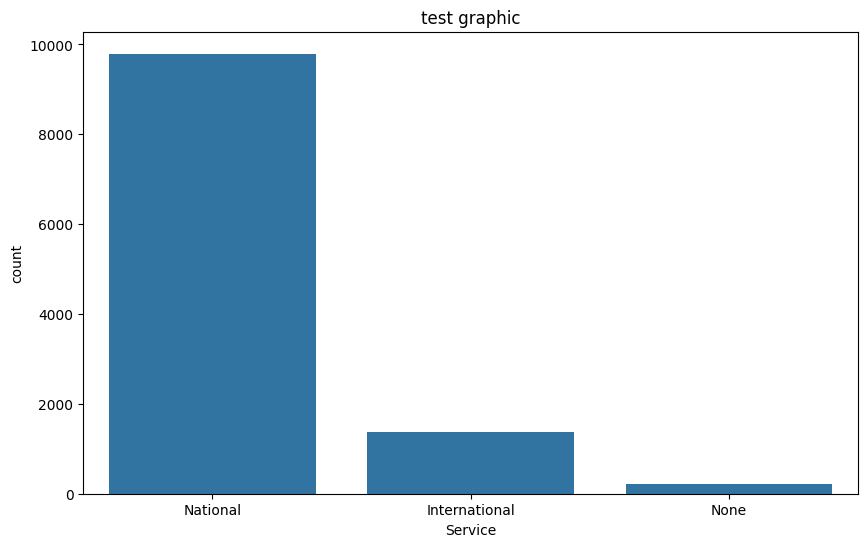

In [63]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Service')
plt.title("test graphic")
plt.show()

test graphic
USE : print a test graphic (bar graph)
PARAMS : df (dataset)
RETURN : bar graph of "Service"

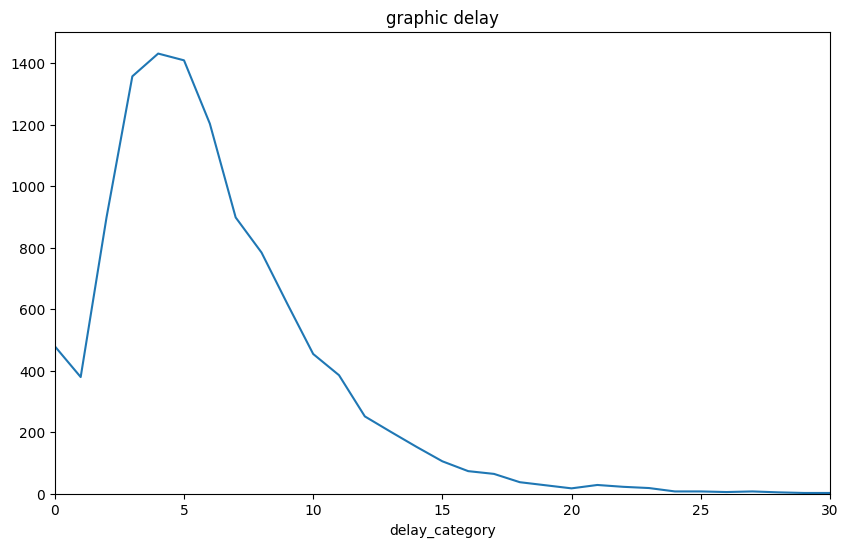

In [64]:
counts = df['delay_category'].value_counts()

plt.figure(figsize=(10, 6))
sns.lineplot(x=counts.index, y=counts.values)
plt.xlim(0, 30)
plt.ylim(0)
plt.title("graphic delay")
plt.show()

graphic delay
USE : print a graphic delay (line graph)
PARAMS : df (dataset)
RETURN : line graph of "delay"